1. Khai báo thư viện ảnh

In [8]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as NguyenPhuocThanh


Kiểm tra opencv đọc ảnh và đặt ảnh cho đúng hiển thị ban đầu

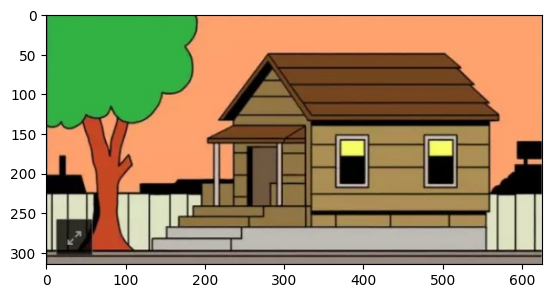

In [29]:
img = cv.imread('hinh1.jpg')
NguyenPhuocThanh.imshow(img[:,:,::-1])


2. Sử dụng Harris Corner Detection tìm các keypoint trong ảnh.
Tham khảo tại:
https://docs.opencv.org/3.4/dc/d0d/tutorial_py_features_harris.html


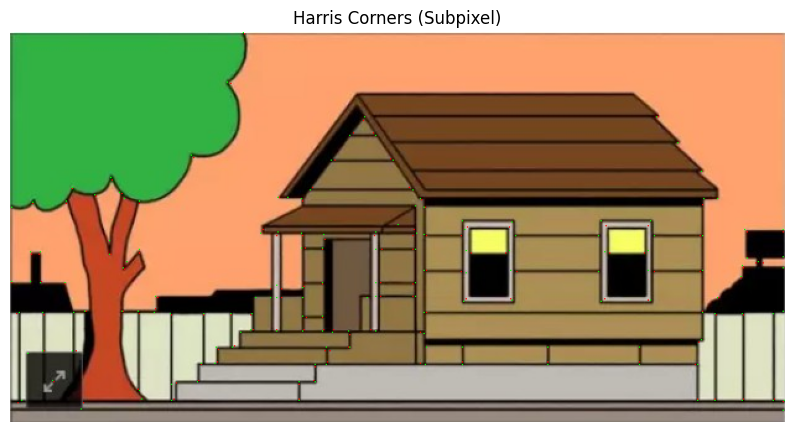

In [30]:
filename = 'hinh1.jpg'
img = cv.imread(filename)
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
# find Harris corners
gray = np.float32(gray)
dst = cv.cornerHarris(gray,2,3,0.04)
dst = cv.dilate(dst,None)
ret, dst = cv.threshold(dst,0.01*dst.max(),255,0)
dst = np.uint8(dst)
# find centroids
ret, labels, stats, centroids = cv.connectedComponentsWithStats(dst)
# define the criteria to stop and refine the corners
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.001)
corners = cv.cornerSubPix(gray,np.float32(centroids),(5,5),(-1,-1),criteria)
# Now draw them
res = np.hstack((centroids,corners))
res = res.astype(int)
img[res[:,1],res[:,0]]=[0,0,255]
img[res[:,3],res[:,2]] = [0,255,0]

NguyenPhuocThanh.figure(figsize=(10, 10))
NguyenPhuocThanh.imshow(img[:,:,::-1])
NguyenPhuocThanh.title('Harris Corners (Subpixel)')
NguyenPhuocThanh.axis('off')
NguyenPhuocThanh.show()

3. Sử dụng Band-pass filtering by Difference of Gaussians

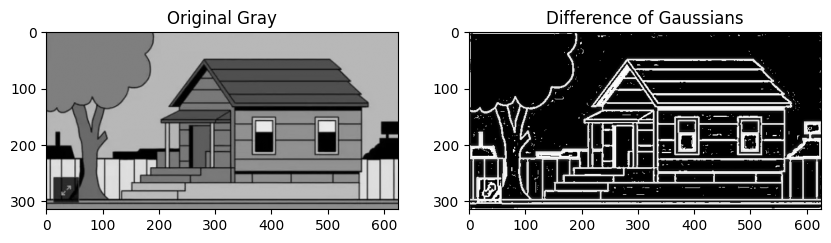

In [13]:
# Read the image
img = cv.imread('hinh1.jpg', 0) # Read as grayscale

# Apply Gaussian Blur with two different standard deviations
blur1 = cv.GaussianBlur(img, (0, 0), 1.0)
blur2 = cv.GaussianBlur(img, (0, 0), 2.0)

# Calculate Difference of Gaussians
dog = blur1 - blur2

# Normalize for visualization
dog_normalized = cv.normalize(dog, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

# Display results
NguyenPhuocThanh.figure(figsize=(10, 5))
NguyenPhuocThanh.subplot(1, 2, 1)
NguyenPhuocThanh.imshow(img, cmap='gray')
NguyenPhuocThanh.title('Original Gray')

NguyenPhuocThanh.subplot(1, 2, 2)
NguyenPhuocThanh.imshow(dog_normalized, cmap='gray')
NguyenPhuocThanh.title('Difference of Gaussians')
NguyenPhuocThanh.show()

4. Kiểm tra ảnh qua Automatic Scale Selection

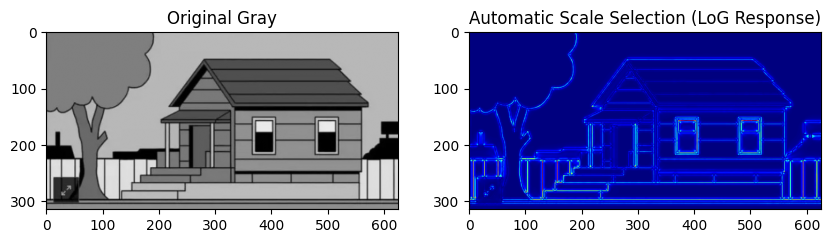

In [17]:
import numpy as np
import cv2 as cv

# Load image as grayscale
img = cv.imread('hinh1.jpg', 0)
img = img.astype(np.float32) / 255.0

# Parameters
k = 1.25
sigma = 1.0
levels = 10
scale_space = []

# Build Laplacian Scale Space (Normalized LoG)
for i in range(levels):
    curr_sigma = sigma * (k**i)
    # Normalized Laplacian: sigma^2 * del^2(G)
    filtered = cv.GaussianBlur(img, (0, 0), curr_sigma)
    laplacian = cv.Laplacian(filtered, cv.CV_32F)
    scale_space.append(np.square(curr_sigma * laplacian))

scale_space = np.array(scale_space)

# Find maximum across scales
max_scale_response = np.max(scale_space, axis=0)

# Visualization
NguyenPhuocThanh.figure(figsize=(10, 5))
NguyenPhuocThanh.subplot(1, 2, 1)
NguyenPhuocThanh.imshow(img, cmap='gray')
NguyenPhuocThanh.title('Original Gray')

NguyenPhuocThanh.subplot(1, 2, 2)
NguyenPhuocThanh.imshow(max_scale_response, cmap='jet')
NguyenPhuocThanh.title('Automatic Scale Selection (LoG Response)')
NguyenPhuocThanh.show()

5. Kiểm tra ảnh qua Scale Invariant Detection

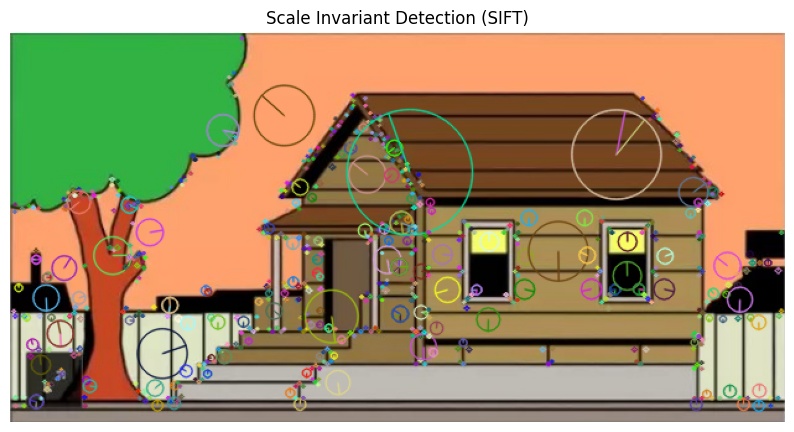

Số lượng keypoints tìm thấy: 766


In [18]:
# Read the image
img = cv.imread('hinh1.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Initialize SIFT detector
sift = cv.SIFT_create()

# Find keypoints and descriptors
keypoints, descriptors = sift.detectAndCompute(gray, None)

# Draw keypoints with size and orientation
img_sift = cv.drawKeypoints(img, keypoints, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Display the results
NguyenPhuocThanh.figure(figsize=(10, 10))
NguyenPhuocThanh.imshow(img_sift[:,:,::-1])
NguyenPhuocThanh.title('Scale Invariant Detection (SIFT)')
NguyenPhuocThanh.axis('off')
NguyenPhuocThanh.show()

print(f"Số lượng keypoints tìm thấy: {len(keypoints)}")

6. Kiểm tra ảnh qua Scale-space blob detector.

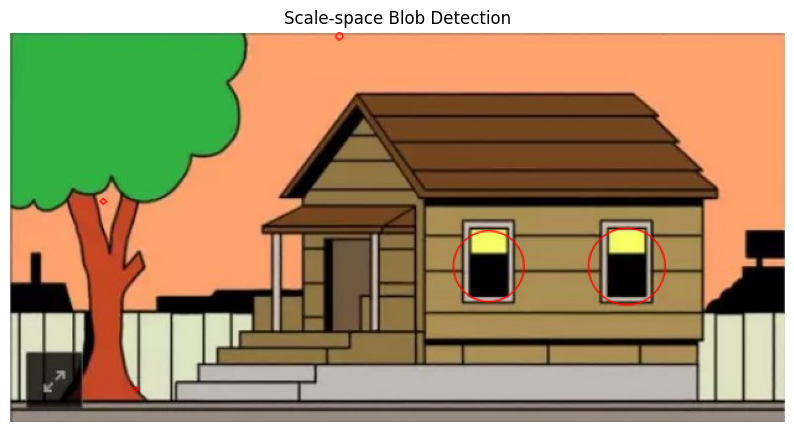

Số lượng blobs tìm thấy: 5


In [19]:
import cv2 as cv
import numpy as np

# Read image
img = cv.imread('hinh1.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Setup SimpleBlobDetector parameters
params = cv.SimpleBlobDetector_Params()

# Filter by Area
params.filterByArea = True
params.minArea = 10

# Filter by Circularity
params.filterByCircularity = True
params.minCircularity = 0.1

# Filter by Convexity
params.filterByConvexity = True
params.minConvexity = 0.87

# Filter by Inertia
params.filterByInertia = True
params.minInertiaRatio = 0.01

# Create a detector with the parameters
detector = cv.SimpleBlobDetector_create(params)

# Detect blobs
keypoints = detector.detect(gray)

# Draw detected blobs as red circles
# cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS ensures the size of the circle corresponds to the size of blob
img_blobs = cv.drawKeypoints(img, keypoints, np.array([]), (0,0,255), cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Show results
NguyenPhuocThanh.figure(figsize=(10, 10))
NguyenPhuocThanh.imshow(img_blobs[:,:,::-1])
NguyenPhuocThanh.title('Scale-space Blob Detection')
NguyenPhuocThanh.axis('off')
NguyenPhuocThanh.show()

print(f"Số lượng blobs tìm thấy: {len(keypoints)}")

7. Thực hành với Bag-of-words detection

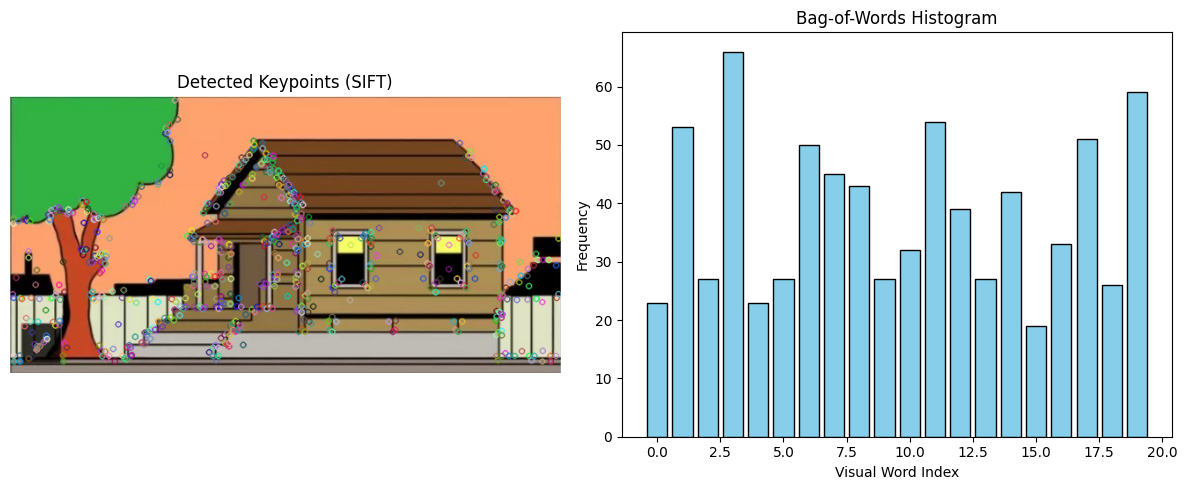

Tổng số đặc trưng: 766
Histogram BoW (20 bins): [23 53 27 66 23 27 50 45 43 27 32 54 39 27 42 19 33 51 26 59]


In [20]:
import cv2 as cv
import numpy as np
from sklearn.cluster import KMeans

# 1. Read image and extract SIFT descriptors
img = cv.imread('hinh1.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
sift = cv.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray, None)

# 2. Create Visual Vocabulary (using KMeans)
# For demonstration, we cluster the descriptors of this single image into 20 visual words
num_clusters = 20
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
kmeans.fit(descriptors)

# 3. Image Representation as Histogram of Visual Words
visual_words = kmeans.predict(descriptors)
histogram, bin_edges = np.histogram(visual_words, bins=num_clusters, range=(0, num_clusters))

# 4. Visualization
NguyenPhuocThanh.figure(figsize=(12, 5))

# Show Keypoints
NguyenPhuocThanh.subplot(1, 2, 1)
img_kp = cv.drawKeypoints(img, keypoints, None)
NguyenPhuocThanh.imshow(img_kp[:,:,::-1])
NguyenPhuocThanh.title('Detected Keypoints (SIFT)')
NguyenPhuocThanh.axis('off')

# Show BoW Histogram
NguyenPhuocThanh.subplot(1, 2, 2)
NguyenPhuocThanh.bar(range(num_clusters), histogram, color='skyblue', edgecolor='black')
NguyenPhuocThanh.title('Bag-of-Words Histogram')
NguyenPhuocThanh.xlabel('Visual Word Index')
NguyenPhuocThanh.ylabel('Frequency')

NguyenPhuocThanh.tight_layout()
NguyenPhuocThanh.show()

print(f"Tổng số đặc trưng: {len(descriptors)}")
print(f"Histogram BoW (20 bins): {histogram}")

8. Ghép ảnh Image Panoramas

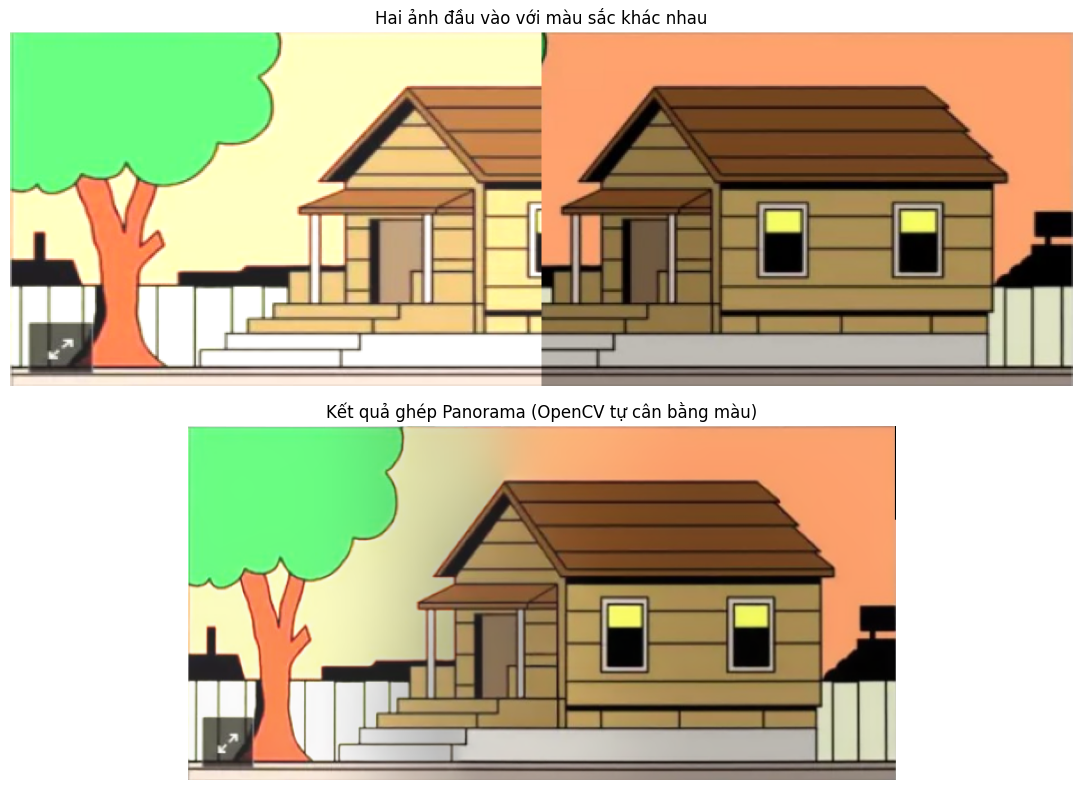

In [43]:
import cv2 as cv
import numpy as np

# Đọc ảnh gốc
original_img = cv.imread('hinh1.jpg')

if original_img is not None:
    height, width = original_img.shape[:2]

    # Cắt 60% bên trái và làm cho nó sáng hơn / ngả màu
    left_part = original_img[:, :int(width * 0.6)].copy()
    # Tăng cường độ sáng cho phần bên trái để tạo sự khác biệt màu sắc
    left_part = cv.convertScaleAbs(left_part, alpha=1.5, beta=30)

    # Cắt 60% bên phải (giữ nguyên màu gốc)
    right_part = original_img[:, int(width * 0.3):].copy()

    imgs = [left_part, right_part]

    # Khởi tạo bộ ghép ảnh (Stitcher)
    stitcher = cv.Stitcher_create()
    status, pano = stitcher.stitch(imgs)

    if status == cv.Stitcher_OK:
        NguyenPhuocThanh.figure(figsize=(15, 8))

        # Hiển thị 2 phần ảnh đầu vào
        NguyenPhuocThanh.subplot(2, 1, 1)
        combined_input = np.hstack((cv.resize(left_part, (300, 200)), cv.resize(right_part, (300, 200))))
        NguyenPhuocThanh.imshow(combined_input[:,:,::-1])
        NguyenPhuocThanh.title('Hai ảnh đầu vào với màu sắc khác nhau')
        NguyenPhuocThanh.axis('off')

        # Hiển thị kết quả ghép
        NguyenPhuocThanh.subplot(2, 1, 2)
        NguyenPhuocThanh.imshow(pano[:,:,::-1])
        NguyenPhuocThanh.title('Kết quả ghép Panorama (OpenCV tự cân bằng màu)')
        NguyenPhuocThanh.axis('off')

        NguyenPhuocThanh.tight_layout()
        NguyenPhuocThanh.show()
    else:
        print(f"Ghép ảnh thất bại. Mã lỗi: {status}")
else:
    print("Không tìm thấy tệp hinh1.jpg.")

9. Ghép ảnh Automatic mosaicing

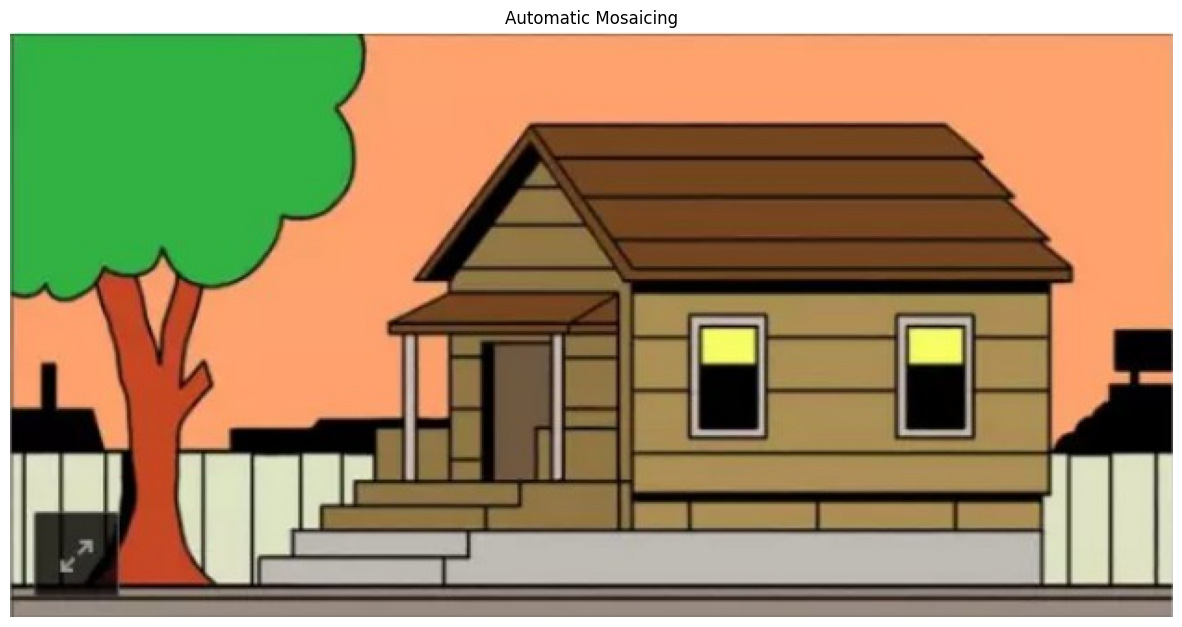

In [81]:
import cv2 as cv
import numpy as np

def automatic_mosaicing(img1, img2):
    sift = cv.SIFT_create()
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    bf = cv.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good.append(m)

    if len(good) > 10:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)

        h1, w1 = img1.shape[:2]
        h2, w2 = img2.shape[:2]

        # Lấy tọa độ các góc của img1 để tính toán kích thước ảnh sau khi warp
        pts = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
        dst = cv.perspectiveTransform(pts, M)

        # Kết hợp với các góc của img2
        img2_pts = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)
        all_pts = np.concatenate((dst, img2_pts), axis=0)

        [x_min, y_min] = np.int32(all_pts.min(axis=0).ravel() - 0.5)
        [x_max, y_max] = np.int32(all_pts.max(axis=0).ravel() + 0.5)

        translation_dist = [-x_min, -y_min]
        H_translation = np.array([[1, 0, translation_dist[0]], [0, 1, translation_dist[1]], [0, 0, 1]])

        # Warp img1 với ma trận dịch chuyển để không bị mất góc
        res = cv.warpPerspective(img1, H_translation.dot(M), (x_max - x_min, y_max - y_min))
        # Đè img2 lên đúng vị trí
        res[translation_dist[1]:h2 + translation_dist[1], translation_dist[0]:w2 + translation_dist[0]] = img2
        return res
    else:
        return None

img_a = cv.imread('hinh1.jpg')
img_b = cv.imread('hinh2.jpg')

if img_a is not None and img_b is not None:
    result = automatic_mosaicing(img_a, img_b)
    if result is not None:
        NguyenPhuocThanh.figure(figsize=(15, 8))
        NguyenPhuocThanh.imshow(result[:,:,::-1])
        NguyenPhuocThanh.title('Automatic Mosaicing')
        NguyenPhuocThanh.axis('off')
        NguyenPhuocThanh.show()
    else:
        print('Không đủ điểm tương đồng.')
else:
    print('Thiếu file ảnh.')

10. Sử dụng Wide base-line stereo

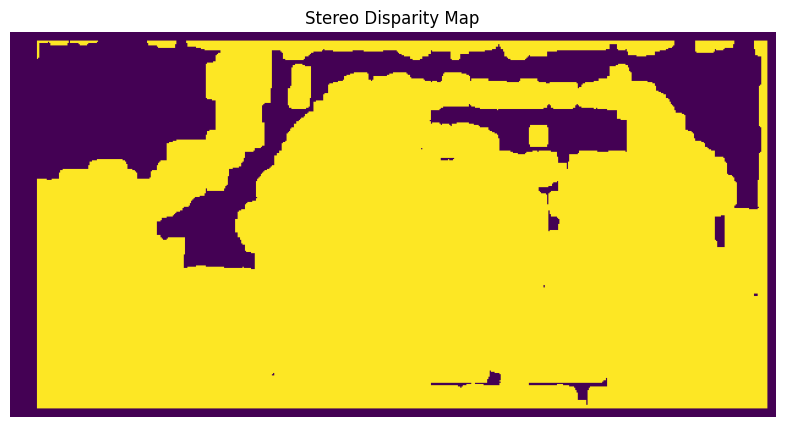

In [98]:
# Đảm bảo img1 và img2 đã được load
import cv2 as cv
import numpy as np

img1 = cv.imread('hinh1.jpg', 0)
img2 = cv.imread('hinh2.jpg', 0)

if img1 is not None and img2 is not None:
    # StereoBM yêu cầu hai ảnh phải có cùng kích thước
    if img1.shape != img2.shape:
        img2 = cv.resize(img2, (img1.shape[1], img1.shape[0]))

    # StereoBM yêu cầu ảnh 8-bit grayscale
    stereo = cv.StereoBM_create(numDisparities=16, blockSize=15)
    disparity = stereo.compute(img1, img2)

    NguyenPhuocThanh.figure(figsize=(10, 5))
    NguyenPhuocThanh.imshow(disparity)
    NguyenPhuocThanh.title("Stereo Disparity Map")
    NguyenPhuocThanh.axis("off")
    NguyenPhuocThanh.show()
else:
    print("Vui lòng đảm bảo hinh1.jpg và hinh2.jpg tồn tại trong thư mục.")

11. CBIR (content-based image retrieval)

In [107]:
import cv2 as cv
import numpy as np

def extract_color_hist(img):
    hist = cv.calcHist([img], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
    return cv.normalize(hist, hist).flatten()

# Giả lập cơ sở dữ liệu ảnh
query_img = cv.imread('hinh1.jpg')
db_images = {'hinh2': cv.imread('hinh2.jpg'), 'hinh3': cv.imread('hinh3.jpg')}

if query_img is not None:
    query_hist = extract_color_hist(query_img)

    print("Kết quả tìm kiếm ảnh tương đồng (CBIR):")
    for name, img_db in db_images.items():
        if img_db is not None:
            db_hist = extract_color_hist(img_db)
            # So sánh bằng phương pháp Correlation (càng gần 1 càng giống)
            score = cv.compareHist(query_hist, db_hist, cv.HISTCMP_CORREL)
            print(f"- Ảnh {name}: Độ tương đồng {score:.4f}")
else:
    print("Không tìm thấy ảnh truy vấn.")

Kết quả tìm kiếm ảnh tương đồng (CBIR):
- Ảnh hinh2: Độ tương đồng 1.0000
- Ảnh hinh3: Độ tương đồng -0.0093


12. Bag-of-word with SIFT + Histogram

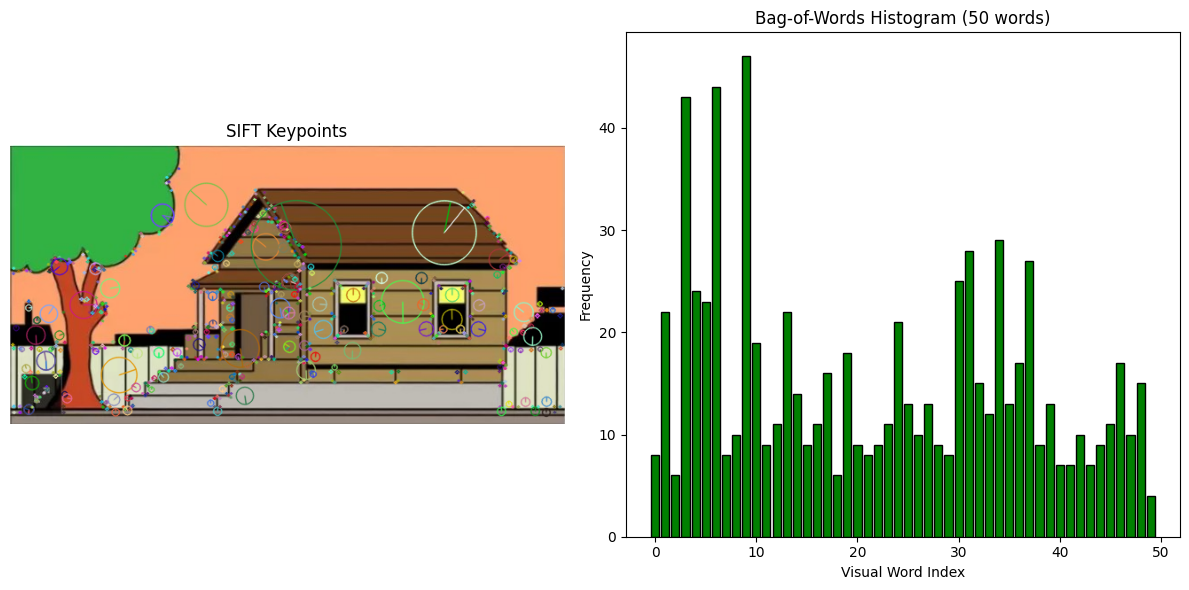

Số lượng đặc trưng trích xuất: 766
Histogram (đầu ra của BoW): 
[ 8 22  6 43 24 23 44  8 10 47 19  9 11 22 14  9 11 16  6 18  9  8  9 11
 21 13 10 13  9  8 25 28 15 12 29 13 17 27  9 13  7  7 10  7  9 11 17 10
 15  4]


In [28]:
import cv2 as cv
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Load image
img = cv.imread('hinh1.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 2. Extract SIFT features
sift = cv.SIFT_create()
kp, des = sift.detectAndCompute(gray, None)

# 3. Create Visual Vocabulary (Clustering)
# We'll cluster the descriptors into 50 visual words for better granularity
num_words = 50
kmeans = KMeans(n_clusters=num_words, random_state=42, n_init=10)
visual_words = kmeans.fit_predict(des)

# 4. Generate Histogram
hist, bins = np.histogram(visual_words, bins=num_words, range=(0, num_words))

# 5. Visualization
NguyenPhuocThanh.figure(figsize=(12, 6))

# Display Original with Keypoints
NguyenPhuocThanh.subplot(1, 2, 1)
img_with_kp = cv.drawKeypoints(img, kp, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
NguyenPhuocThanh.imshow(img_with_kp[:,:,::-1])
NguyenPhuocThanh.title('SIFT Keypoints')
NguyenPhuocThanh.axis('off')

# Display BoW Histogram
NguyenPhuocThanh.subplot(1, 2, 2)
NguyenPhuocThanh.bar(range(num_words), hist, color='green', edgecolor='black')
NguyenPhuocThanh.title(f'Bag-of-Words Histogram ({num_words} words)')
NguyenPhuocThanh.xlabel('Visual Word Index')
NguyenPhuocThanh.ylabel('Frequency')

NguyenPhuocThanh.tight_layout()
NguyenPhuocThanh.show()

print(f'Số lượng đặc trưng trích xuất: {len(des)}')
print(f'Histogram (đầu ra của BoW): \n{hist}')